In [1]:
from langchain_community.document_loaders import DirectoryLoader

pdfs = DirectoryLoader("documentos", glob="*.pdf").load()

len(pdfs)

/var/folders/t0/pj9mr33s4xsdgcv27jrjrpsm0000gn/T/ipykernel_5604/787593888.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader
/Users/devbodegami/Projetos/formacao-especialista-em-ia/.venv-test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No languages specified, defaulting to English.
No languages specified, defaulting to English.
No languages specified, defaulting to English.


3

In [2]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

In [3]:
from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=tokenizer, chunk_size=1250, chunk_overlap=150
)

pedacos = splitter.split_documents(pdfs)
len(pedacos)

37

In [4]:
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="bge-m3:567m")

vector_store = FAISS.from_documents(
    documents=pedacos, embedding=embeddings
)

retriever = vector_store.as_retriever()

In [5]:
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Responda usando exclusivamente o conteúdo fornecido. \n\nContexto: \n{contexto}"),
        ("human", "{query}")
    ]
)

modelo = OllamaLLM(model="gemma3:4b")

In [6]:
import getpass
import os
from langsmith import traceable

langsmith_tracing = os.getenv("LANGSMITH_TRACING")
if not langsmith_tracing:
    langsmith_api_key = getpass.getpass("Enter your LANGSMITH_TRACING: ")

langsmith_api_key = os.getenv("LANGSMITH_API_KEY")
if not langsmith_api_key:
    langsmith_api_key = getpass.getpass("Enter your LANGSMITH_API_KEY: ")

In [9]:
# @traceable
# def rag_trace(pergunta):
#   cadeia = prompt | modelo | StrOutputParser()
#   # retrieve
#   trechos = retriever.invoke(pergunta)
#   # augment
#   contexto = "\n\n".join(um_trecho.page_content for um_trecho in trechos)
#   # generate
#   return cadeia.invoke({ "query": pergunta, "contexto": contexto})

In [ ]:
# pergunta = "Como fazer um seguro viagem?"

# rag_trace(pergunta)

'Com base no texto fornecido, aqui está um guia sobre como obter um seguro viagem MasterAssist Plus, que é oferecido aos portadores de cartões Mastercard Platinum™ e suas famílias:\n\n**1. Elegibilidade:**\n\n*   **Quem é coberto?** O seguro viagem MasterAssist Plus cobre os portadores do cartão Mastercard Platinum™ e seus dependentes (cônjuges, companheiros e filhos dependentes), viajando juntos ou separados.  É importante que todos estejam incluídos no "Bilhete de Seguro Anual" do cartão.\n*   **Mantenha o bilhete atualizado:** Se houver mudanças em seus dependentes (cônjuge, companheiro ou filho), você precisa reemitir seu bilhete de seguro para garantir que a cobertura esteja sempre válida.\n\n**2. Cobertura Oferecida:**\n\nO MasterAssist Plus oferece uma ampla gama de coberturas, incluindo:\n\n*   **Despesas Médicas e Hospitalares em Viagem ao Exterior (Acidente ou Doença Súbita):** Cobre despesas médicas, hospitalares, tratamento dentário (limitado a US$100 por dente), medicament

In [11]:
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"contexto": RunnablePassthrough()  | retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | modelo | StrOutputParser()
)

In [13]:
rag_chain.invoke("Como fazer um seguro viagem?")

'Com base nos documentos fornecidos, aqui estão os passos para obter o seguro viagem MasterAssist Plus:\n\n1.  **Requisitos:** Você precisa ser portador do cartão Mastercard Platinum™ ou ter um dependente (cônjuge, companheiro(a) ou filho(a) dependente) incluído no seu bilhete de seguro anual.\n\n2.  **Atualização do Bilhete:** Se houver alguma mudança em seus dependentes, você precisa reemitir seu bilhete de seguro atualizado.\n\n3.  **Coberturas:** O seguro oferece uma ampla gama de coberturas, incluindo:\n    *   Despesas médicas e hospitalares em viagem ao exterior (acidente ou doença súbita)\n    *   Traslado médico (remoção médica)\n    *   Traslado de corpo (repatriacão funerária)\n    *   Retorno de menores/idosos\n    *   Acompanhante em caso de hospitalização prolongada\n    *   Hospedagem\n\n4. **Despesas Cobertas:** A cobertura inclui despesas médicas como:\n    *   Cobranças feitas por hospitais e médicos\n    *   Medicamentos, raios-x, testes e serviços de laboratório\n  

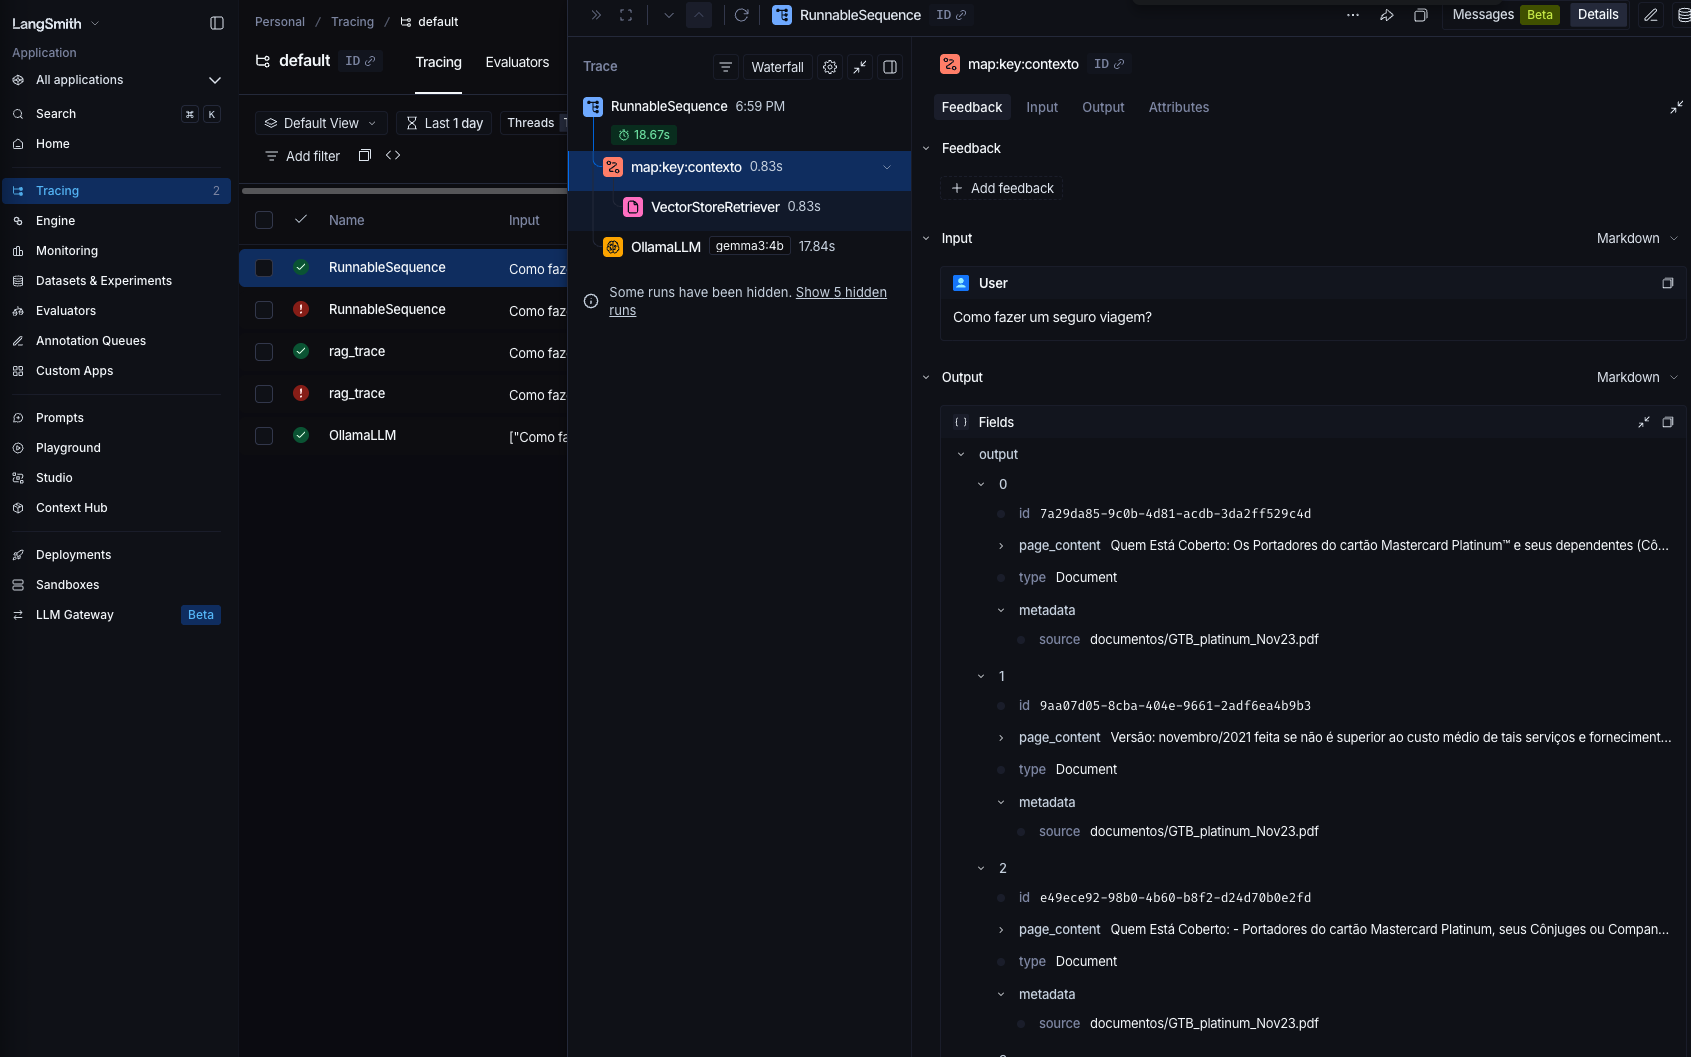